In [2]:
# Celda 1

from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import os
import sys
import shutil
import time
import copy
import datetime
from tqdm import tqdm
#import matplotlib.pyplot as plt
#import seaborn as sns
#import cv2
#from PIL import Image
#from pathlib import Path

import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
import torch.nn.functional as F

from joblib import load, dump

from utils import plot_confusion_matrix

# Appendeo el directorio de una carpeta arriba
nb_dir = os.path.dirname(os.path.abspath("Resnet50_1.0.ipynb"))
dir = os.path.abspath(os.path.join(nb_dir,'..'))
sys.path.append(dir)

from augment.autoaugment import ImageNetPolicy	
from augment.cutout import Cutout
# Verificamos que CUDA está funcional
torch.cuda.is_available()

# Nota: hay que copiar la carpeta augment y el archivo utils (Están en la carpeta de la cátedra,UA_MDM_Labo2) 
# dentro de la carpeta del proyecto (Labo_2_Grupo_15)

c:\Users\GWF-SerIA\anaconda3\envs\ldi2_cuda_Resnet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
# Celda 2
# Seteo del modelo


# Importo modelo ResNet entrenado en Imagenet
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# Modificar la última capa para adaptarse a tu problema específico
num_ftrs = resnet50.fc.in_features
resnet50.fc = torch.nn.Linear(num_ftrs, 5) # Clasificación 5 clases
# Configuro para usar cuda si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)
# Instancio del criterio de pérdida CrossEntropyLoss
criterion = nn.CrossEntropyLoss()



In [4]:
# Celda 3

# Carpetas del grupo
GRUPO_DIR = "Labo_2_Grupo_15"
PATH_GRUPO = 'C:/Users/GWF-SerIA/Documents/GitHub/Labo_2_Grupo_15'
WORK_DIR_NAME = "work"
PATH_IMAGENES = 'C:/Users/GWF-SerIA/Documents/GitHub/UA_MDM_Labo2/input/petfinder-adoption-prediction/train_images'
# Cambiamos el directorio de trabajo de la terminal de Jupyter
os.chdir(r'C:/Users/GWF-SerIA/Documents/Github/Labo_2_Grupo_15')




# Seteo de parámetros directorios y funciones
BASE_DIR = 'C:/Users/GWF-SerIA/Documents/GitHub/UA_MDM_Labo2'
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train.csv")
PATH_TO_IMAGES_DIR = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train_images")
PATH_TO_TEMP_FILES = os.path.join(PATH_GRUPO, "work/optuna_temp_artifacts")
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(PATH_GRUPO, "work/optuna_artifacts")





MODEL_NAME = '04 ResNet Augment'

MODEL_VERSION = '1.0.0'

# Parametros y variables
CREATE_PYTORCH_DIRECTORIES = 1
SEED = 42
BATCH_SIZE = 128
TEST_SIZE = 0.2
IMAGE_SIZE = 299
# Detecta los núcleos
logical_cores = os.cpu_count()

# Usamos la mitad de los núcleos lógicos (en tu caso sería 6)
# O dejamos al menos 2 hilos libres para el sistema
#NUM_WORKERS = max(1, logical_cores // 2) 
NUM_WORKERS = 0

# Armo el nuevo directorio de train
new_train_directory = os.path.join(BASE_DIR, 'work/train_images_classes')
os.makedirs(new_train_directory, exist_ok=True) # si ya existe el nombre, lo deja como está

# Armo el nuevo directorio de validación
new_val_directory = os.path.join(BASE_DIR, 'work/val_images_classes')
os.makedirs(new_val_directory, exist_ok=True)

# Definir las clases ordenadas
class_names = ['0', '1', '2', '3', '4']

# Mapear las etiquetas de las clases a números enteros consecutivos
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

# Creo las carpetas de clases dentro de los directorios
for clase in class_names: # Una para cada clase
   os.makedirs(os.path.join(new_train_directory, str(clase)), exist_ok=True)
   os.makedirs(os.path.join(new_val_directory, str(clase)), exist_ok=True)



In [5]:
# Celda 4

# Carga de archivos desde la carpeta Labo_2_Grupo_15/work


# Este código busca la carpeta 'work' subiendo niveles si es necesario
base_path = os.getcwd()
if GRUPO_DIR in base_path:
    # Si ya estamos dentro de Labo_2_Grupo_15, la carpeta work está al mismo nivel o un nivel arriba
    if os.path.exists(os.path.join(base_path, WORK_DIR_NAME)):
        target_path = os.path.join(base_path, WORK_DIR_NAME)
    else:
        # Probablemente estamos en una subcarpeta (ej: notebooks/)
        target_path = os.path.join(base_path, '..', WORK_DIR_NAME)
else:
    # Si estamos fuera, entramos a la carpeta del grupo
    target_path = os.path.join(base_path, GRUPO_DIR, WORK_DIR_NAME)

# 3. Construimos las rutas de los archivos
train_path = os.path.join(target_path, "df_train_split.csv")
test_path = os.path.join(target_path, "df_test_split.csv")

# 4. Cargamos los DataFrames
if os.path.exists(train_path) and os.path.exists(test_path):
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"✅ Éxito: Particiones cargadas desde {target_path}")
    print(f"📊 Train: {len(df_train)} filas | Test: {len(df_test)} filas")
else:
    print(f"❌ Error: No se encontraron los archivos en {target_path}")
    print("Asegúrate de haber corrido el notebook de preparación primero.")

✅ Éxito: Particiones cargadas desde C:\Users\GWF-SerIA\Documents\Github\Labo_2_Grupo_15\work
📊 Train: 11994 filas | Test: 2999 filas


In [6]:
# Celda 5 verificaciones del dataset

# Verificamos los primeros registros
print("\nPrimeras filas del set de entrenamiento:")
print(df_train[['PetID', 'AdoptionSpeed']].head())

# Verificamos que no haya nulos en el target
if df_train['AdoptionSpeed'].isnull().any():
    print("⚠️ ¡Cuidado! Hay valores nulos en el target de entrenamiento.")


Primeras filas del set de entrenamiento:
       PetID  AdoptionSpeed
0  23b64fe21              2
1  6e09bfe1f              3
2  48a44eac5              4
3  ae219ff80              1
4  e13c47053              2


In [7]:
# Funciones de Carga y Preproceso


def visualize_pet(pet_id):
    path_to_image = os.path.join(PATH_TO_IMAGES_DIR, f'{pet_id}-1.jpg') # Irá a la primera imagen de la mascota
    # Cargar la imagen
    image_to_show = cv2.imread(path_to_image)
    # Convertir a formato RGB
    image_to_show = cv2.cvtColor(image_to_show, cv2.COLOR_BGR2RGB)
    # Visualizar la imagen
    plt.imshow(image_to_show)
    plt.axis('off')  # No mostrar los ejes
    plt.show()

def visualize_image(image):
    # Convierte la imagen a un formato de enteros (CV_8U)
    image = cv2.convertScaleAbs(image)
    image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Visualizar la imagen
    plt.imshow(image.astype(np.uint8))
    plt.axis('off')  # No mostrar los ejes
    plt.show()


In [8]:
#  Carga y procesado de datos
#  Nota: Pytorch necesita que estén las imágenes en los distintos directorios según su clase y su participación en el training

train_data = df_train
val_data =  df_test 


if CREATE_PYTORCH_DIRECTORIES == 1: # Poner en 0 si ya tengo las carpetas train_images_classes y val_images_classes con las imágenes copiadas
    # Función para copiar las imágenes a los directorios correspondientes
    def copy_imag(data, directorio_destino):
        for index, row in data.iterrows():
            petID = row['PetID']
            adoption_speed = row['AdoptionSpeed']
            
            # Nombre del archivo de imagen
            nombre_archivo = f"{petID}-1.jpg"
            
            # Ruta completa de la imagen de origen
            ruta_origen = os.path.join(PATH_TO_IMAGES_DIR, nombre_archivo)
            
            # Ruta completa del directorio de destino
            ruta_destino = os.path.join(directorio_destino, str(adoption_speed), nombre_archivo)
            
            # Verificar si el archivo de origen existe
            if os.path.exists(ruta_origen):
                # Copiar el archivo de origen al directorio de destino
                shutil.copy2(ruta_origen, ruta_destino)
        print("Completada la copia a: ",str(directorio_destino))

    # Copiar las imágenes al directorio de train
    copy_imag(train_data, new_train_directory)

    # Copiar las imágenes al directorio de val
    copy_imag(val_data, new_val_directory)

    print("Proceso completado.")

Completada la copia a:  C:/Users/GWF-SerIA/Documents/GitHub/UA_MDM_Labo2\work/train_images_classes
Completada la copia a:  C:/Users/GWF-SerIA/Documents/GitHub/UA_MDM_Labo2\work/val_images_classes
Proceso completado.


In [9]:
##### Nueva Clase para generar los 2046 valores que luego se pasaran al PCA ############################# 

from torch.utils.data import Dataset
from PIL import Image
import os

class PetDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images_names = []
        
        # 1. Recolectamos las rutas de las imágenes
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file.endswith(('.jpg', '.png', '.jpeg')):
                    self.images_names.append(os.path.join(root, file))
        
        # 2. AGREGAMOS ESTA LÍNEA: Creamos el atributo 'samples' 
        # para que sea compatible con el resto de tu notebook.
        # Guardamos la ruta completa para poder procesarla después.
        self.samples = self.images_names 

    def __len__(self):
        return len(self.images_names)

    def __getitem__(self, idx):
        img_path = self.images_names[idx]
        image = Image.open(img_path).convert('RGB')
        
        # Extraemos el PetID del nombre del archivo
        filename = os.path.basename(img_path)
        petid = filename.split('-')[0].split('.')[0]
        
        # Extraemos el label (nombre de la carpeta madre)
        # Asegúrate de que tus carpetas se llamen "0", "1", "2", etc.
        try:
            label = int(os.path.basename(os.path.dirname(img_path)))
        except ValueError:
            label = 0 # Valor por defecto si la carpeta no es un número
        
        if self.transform:
            image = self.transform(image)
            
        return image, label, petid

In [10]:
# Genero los DataLoaders


def create_dataloaders(train_directory, val_directory, batch_size, num_workers):
    # Transformaciones de imagen para el conjunto de entrenamiento
    train_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        ImageNetPolicy(),  ############### LAS POLÍTICAS AUTOAUGMENT PARA IMAGENET (AUGMENT)
        transforms.ToTensor(),
        Cutout(n_holes=1, length = 16),   ############### CUTOUT PARA REGULARIZACIÓN (AUGMENT)
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Transformaciones de imagen para el conjunto de validación (sin data augment)
    val_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Crear conjuntos de datos para el conjunto de entrenamiento y validación
    conjunto_entrenamiento = datasets.ImageFolder(train_directory, transform=train_transforms)
    conjunto_validacion = datasets.ImageFolder(val_directory, transform=val_transforms)

    # Asignar las clases ordenadas al conjunto de datos
    conjunto_entrenamiento.class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}
    conjunto_validacion.class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

    ###############################################cambio260426########################################################################

    # CAMBIO AQUÍ: Usamos nuestra clase personalizada
    conjunto_entrenamiento = PetDataset(root_dir=train_directory, transform=train_transforms)
    conjunto_validacion = PetDataset(root_dir=val_directory, transform=val_transforms)

    # El resto de la función queda igual, pero recordá que ahora 
    # tus loaders devolverán 3 cosas en lugar de 2.

    ###################################################Cambio260426####################################################################

    # Crear dataloaders para el conjunto de entrenamiento y validación
    train_dataloader = torch.utils.data.DataLoader(conjunto_entrenamiento, batch_size=batch_size, shuffle=True, num_workers=num_workers,pin_memory=True)
    val_dataloader = torch.utils.data.DataLoader(conjunto_validacion, batch_size=batch_size, shuffle=False, num_workers=num_workers,pin_memory=True)

    return train_dataloader, val_dataloader

# Aplico las funcion de los DataLoaders
train_dataloader, val_dataloader = create_dataloaders(new_train_directory , new_val_directory , BATCH_SIZE, NUM_WORKERS)


In [11]:
#Genero una lista de PetIDs con imagen en el orden en que aparecen en el data loader
#test_sample_ids = [i[0].split('/')[-1].split('-')[0] for i in val_dataloader.dataset.samples]
# Ahora 'samples' es una lista de rutas (strings)
test_sample_ids = [os.path.basename(path).split('-')[0].split('.')[0] for path in val_dataloader.dataset.samples]

In [12]:
# Modificamos los parámetros de entrada y el optimizador
def train_val(model, criterion, dataloaders, datasets, device, num_epochs=20, lr=0.001, momentum=0.9, weight_decay=0.0, optimizer_name='SGD', trial=None):
    
    # Instancio el optimizador elegido por Optuna
    if optimizer_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
        
    # Inicializo variables
    since = time.time()

####################  Código modificado 270426  ######################################################

    #Inicializo variable de mejor kappa entre trials
    try:
        #Intento obtener el mejor kappa de optuna
        previous_best = study.best_value
    except:
        #Si no hay, seteo -999
        previous_best = -999

    #Inicializo variables de mejor modelo y mejor accuracy y mejor kappa de este trial
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_kappa =  -999


    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)
        
        #Inicializo listas de kappa true y predicted y scores para esta epoch
        epoch_kappa_labels_true = []
        epoch_kappa_labels_predicted = []
        epoch_output_scores = []
        epoch_petids = [] # <-- CAMBIO: Lista para guardar los IDs de esta época


        #Cada epoch tiene una fase de entrenamiento y validación
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            #Inicializo variables de loss y accuracy para esta fase de epoch
            epoch_phase_running_loss = 0.0
            epoch_phase_running_corrects = 0

            # Itero sobre los datos.
            for inputs, labels, petids in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    elif phase == 'val':
                        #Agrego los valores de kappa true y predicted para cada batch en validación
                        epoch_kappa_labels_true.extend(labels.cpu().numpy().tolist())
                        epoch_kappa_labels_predicted.extend(preds.cpu().numpy().tolist())

                        # Guardamos los scores y los petids sincronizados
                        outputs_np = outputs.cpu().numpy()
                        epoch_output_scores.extend([outputs_np[i,:] for i in range(outputs_np.shape[0])])
                        epoch_petids.extend(petids) # <-- CAMBIO: Guardamos el ID real

                # Statistics for each phase
                epoch_phase_running_loss += loss.item() * inputs.size(0)
                epoch_phase_running_corrects += torch.sum(preds == labels.data)
                
                #END OF BATCH

            epoch_loss = epoch_phase_running_loss / len(datasets[phase])
            epoch_acc = epoch_phase_running_corrects.double() / len(datasets[phase])
            
            #Calculo el kappa para cada epoch
            if phase == 'train':
                #overall_train_losses.append(epoch_loss)
                current_kappa_score = np.nan
            else:
                #overall_val_losses.append(epoch_loss)
                current_kappa_score = cohen_kappa_score(epoch_kappa_labels_true,
                                  epoch_kappa_labels_predicted,
                                  weights = 'quadratic')
                    


            print(f'{phase.title()} Loss: {epoch_loss:.4f} Acc: {epoch_acc*100:.2f}% Kappa: {current_kappa_score:.3f}')

            # If this is the best Epoch so far -> Deep copy the model
            if phase == 'val' and current_kappa_score > best_kappa:
                best_acc = epoch_acc
                best_kappa = current_kappa_score
                best_model_wts = copy.deepcopy(model.state_dict())


                #Best Epoch within a trial and better than previous trials
                if trial is not None and best_kappa > previous_best:

                    #Save test dataset with predictions
                    predicted_filename = os.path.join(PATH_TO_TEMP_FILES,f'test_{trial.study.study_name}_{trial.number}.joblib')
                    predicted_df = pd.DataFrame({'PetID':test_sample_ids,
                                'pred':epoch_output_scores}).merge(val_data, on='PetID')
                    dump(predicted_df, predicted_filename)

                    #Generate and save CM 
                    cm_filename = os.path.join(PATH_TO_TEMP_FILES,f'cm_{trial.study.study_name}_{trial.number}.jpg')
                    plot_confusion_matrix(epoch_kappa_labels_true,epoch_kappa_labels_predicted).write_image(cm_filename)

            #END OF PHASE

        # --- INICIO CAMBIO PARA OPTUNA PRUNING ---Cambio 270426

        # Le informamos a Optuna cómo le fue a esta época.
        if trial is not None:
            trial.report(current_kappa_score, epoch)
            
            # Si el trial es mediocre, Optuna levanta una excepción y lo corta para ahorrar tiempo
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
            
        # --- FIN CAMBIO ---Cambio 270426

        #END OF EPOCH

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:.2f}%'.format(best_acc * 100))

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Save in optuna trial the best test dataset, cm and model weights
    if trial is not None and best_kappa > previous_best:
        #upload_artifact(trial, predicted_filename, artifact_store)
        upload_artifact(trial,predicted_filename,artifact_store)   

        upload_artifact(trial, cm_filename, artifact_store)

        file_name = f'{MODEL_NAME}_{MODEL_VERSION}_{trial.number}.pth'
        model_path = os.path.join(PATH_TO_TEMP_FILES, file_name)
        torch.save(model, model_path) # Podemos guardar solo los pesos si queremos: best_model.state_dict()
        upload_artifact(trial, model_path, artifact_store)

    return model,best_kappa


In [13]:
import gc

artifact_store = FileSystemArtifactStore(base_path=PATH_TO_OPTUNA_ARTIFACTS)

def optuna_train(trial):
    # --- LIMPIEZA ---
    gc.collect()
    torch.cuda.empty_cache()
    # ----------------
    # Fijamos las epochs altas, el pruner cortará antes de ser necesario
    epochs = 8

    # Hiperparámetros a optimizar (los que realmente importan)
    # lr = trial.suggest_float('lr',0.001, 0.04, log=True)
    # weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    # optimizer_name = trial.suggest_categorical('optimizer', ['AdamW', 'SGD'])
    lr = trial.suggest_float("lr",  1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay",  1e-3, 0.1, log=True)
    optimizer_name = 'AdamW'
    # Solo usamos momentum si el optimizador es SGD
    momentum = trial.suggest_float('momentum', 0.0, 0.95) if optimizer_name == 'SGD' else 0.9

    _,best_score = train_val(resnet50, criterion, 
                       dataloaders={'train': train_dataloader, 
                                    'val': val_dataloader}, 
                       datasets={'train': train_data, 'val': val_data}, 
                       device=device, 
                       num_epochs=epochs,
                       lr=lr,
                       momentum=momentum,
                       weight_decay=weight_decay,
                       optimizer_name=optimizer_name,
                       trial=trial)

    return(best_score)


In [14]:
import os

# La ruta relativa que estás usando
ruta_relativa = "../Labo_2_Grupo_15/work/db.sqlite3"

# Convertirla a ruta absoluta basada en donde está el notebook actualmente
ruta_absoluta = os.path.abspath(ruta_relativa)

print(f"El directorio actual del notebook es: {os.getcwd()}")
print(f"Tu base de datos se está buscando en: {ruta_absoluta}")

# Verificar si la carpeta 'work' existe en esa ruta
folder_work = os.path.dirname(ruta_absoluta)
if os.path.exists(folder_work):
    print(f"✅ La carpeta '{folder_work}' SÍ existe.")
else:
    print(f"❌ La carpeta '{folder_work}' NO existe. Por eso falla SQLite.")


El directorio actual del notebook es: C:\Users\GWF-SerIA\Documents\Github\Labo_2_Grupo_15
Tu base de datos se está buscando en: C:\Users\GWF-SerIA\Documents\Github\Labo_2_Grupo_15\work\db.sqlite3
✅ La carpeta 'C:\Users\GWF-SerIA\Documents\Github\Labo_2_Grupo_15\work' SÍ existe.


In [15]:
import os

# 1. Definimos la ruta base (la que confirmamos antes)
base_path = r'C:/Users/GWF-SerIA/Documents/GitHub/Labo_2_Grupo_15'

# 2. Creamos la carpeta de artefactos (donde falla el joblib.dump)
artifacts_path = os.path.join(base_path, 'work', 'optuna_temp_artifacts')
os.makedirs(artifacts_path, exist_ok=True)

print(f"✅ Carpeta lista en: {artifacts_path}")


✅ Carpeta lista en: C:/Users/GWF-SerIA/Documents/GitHub/Labo_2_Grupo_15\work\optuna_temp_artifacts


In [15]:
# El Pruner espera 3 épocas antes de empezar a evaluar si corta o no un entrenamiento
pruner = optuna.pruners.MedianPruner(n_warmup_steps=3)

study = optuna.create_study(direction='maximize',
                            storage="sqlite:///../Labo_2_Grupo_15/work/db.sqlite3",
                            study_name=f'{MODEL_NAME}_{MODEL_VERSION}',
                            load_if_exists=True,
                            pruner=pruner) # <--- Agregamos el pruner aquí

# Subimos los trials a 50
study.optimize(optuna_train, n_trials=30)

[I 2026-04-29 18:42:10,340] Using an existing study with name '04 ResNet Augment_1.0.0' instead of creating a new one.


Epoch 0/7
----------


  4%|▍         | 4/92 [00:18<06:51,  4.67s/it]
[W 2026-04-29 18:42:29,271] Trial 41 failed with parameters: {'lr': 1.2533014604949696e-05, 'weight_decay': 0.0077972772166660775} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\GWF-SerIA\anaconda3\envs\ldi2_cuda_Resnet\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_9164\3726714742.py", line 23, in optuna_train
    _,best_score = train_val(resnet50, criterion,
  File "C:\Users\GWF-SerIA\AppData\Local\Temp\ipykernel_9164\2623186825.py", line 81, in train_val
    epoch_phase_running_loss += loss.item() * inputs.size(0)
KeyboardInterrupt
[W 2026-04-29 18:42:29,271] Trial 41 failed with value None.


KeyboardInterrupt: 

In [16]:
import optuna

# 1. Definir la URL de la base de datos y el nombre del estudio exactamente como antes
storage_url = "sqlite:///../Labo_2_Grupo_15/work/db.sqlite3"
study_name = f'{MODEL_NAME}_{MODEL_VERSION}'

# 2. Cargar el estudio existente
study = optuna.load_study(
    study_name=study_name, 
    storage=storage_url
)

# 3. Ahora ya podés acceder a los mejores parámetros
best_params = study.best_params
print(f"Mejores hiperparámetros recuperados: {best_params}")
best_trial = study.best_trial
print(f"El mejor fue el Trial número: {best_trial.number}")
print(f"Logró un Kappa de: {best_trial.value:.4f}")


Mejores hiperparámetros recuperados: {'lr': 4.479727192037496e-05, 'weight_decay': 0.01959856566281532}
El mejor fue el Trial número: 11
Logró un Kappa de: 0.3245


In [16]:
import gc


# --- LIMPIEZA VRAM---
gc.collect()
torch.cuda.empty_cache()
# ----------------


import datetime

# 1. Recuperamos los mejores hiperparámetros del Study
best_params = study.best_params
print(f"Mejores hiperparámetros de Optuna: {best_params}")

# Asignamos los mejores parámetros (si optimizaste más cosas, agrégalas aquí)
best_lr = best_params['lr']
best_weight_decay = best_params['weight_decay']

# 2. Entrenamos el modelo con estos parámetros (te sugiero poner un buen número de épocas)
best_model, _ = train_val(
    resnet50, 
    criterion, 
    dataloaders={'train': train_dataloader, 'val': val_dataloader}, 
    datasets={'train': train_data, 'val': val_data}, 
    device=device, 
    num_epochs=3, 
    lr=4.479737192037496e-05,
    weight_decay=best_weight_decay, 
    optimizer_name='AdamW' # Fijo, tal como lo dejaste en tu función optuna_train
)

# 3. Guardamos el modelo
run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f'{MODEL_NAME}_{MODEL_VERSION}_BEST_{run_id}.pth'
model_path = os.path.join(PATH_TO_TEMP_FILES, file_name)

# Guardamos el modelo completo (o solo los pesos con best_model.state_dict())
torch.save(best_model, model_path) 
print(f'Modelo guardado exitosamente en: {model_path}')

Mejores hiperparámetros de Optuna: {'lr': 4.479727192037496e-05, 'weight_decay': 0.01959856566281532}
Epoch 0/2
----------


100%|██████████| 92/92 [03:32<00:00,  2.31s/it]


Train Loss: 1.4375 Acc: 30.80% Kappa: nan


100%|██████████| 23/23 [00:32<00:00,  1.43s/it]


Val Loss: 1.3721 Acc: 34.38% Kappa: 0.297
Epoch 1/2
----------


...

Val Loss: 1.3607 Acc: 35.08% Kappa: 0.296
Epoch 2/2
----------


100%|██████████| 92/92 [02:22<00:00,  1.55s/it]


Train Loss: 1.2878 Acc: 40.77% Kappa: nan


100%|██████████| 23/23 [00:16<00:00,  1.43it/s]

Val Loss: 1.3572 Acc: 36.05% Kappa: 0.321
Training complete in 9m 26s
Best val Acc: 36.05%
Modelo guardado exitosamente en: C:/Users/GWF-SerIA/Documents/GitHub/Labo_2_Grupo_15\work/optuna_temp_artifacts\04 ResNet Augment_1.0.0_BEST_20260429_185532.pth


In [19]:
# Carga el mejor modelo

# Define la ruta donde se encuentra el archivo
model_path = 'work/optuna_temp_artifacts/04 ResNet Augment_1.0.0_BEST_20260429_185532.pth'

# Carga del modelo
# Usamos map_location=device para que se adapte automáticamente a la RTX o CPU
best_model = torch.load(model_path, map_location=device)

# Es fundamental ponerlo en modo evaluación para inferencia/test
best_model.eval()

print(f"Modelo {model_path} cargado correctamente.")

Modelo work/optuna_temp_artifacts/04 ResNet Augment_1.0.0_BEST_20260429_185532.pth cargado correctamente.


Calculando inferencia sobre el set de prueba...

Quadratic Weighted Kappa Final: 0.3206


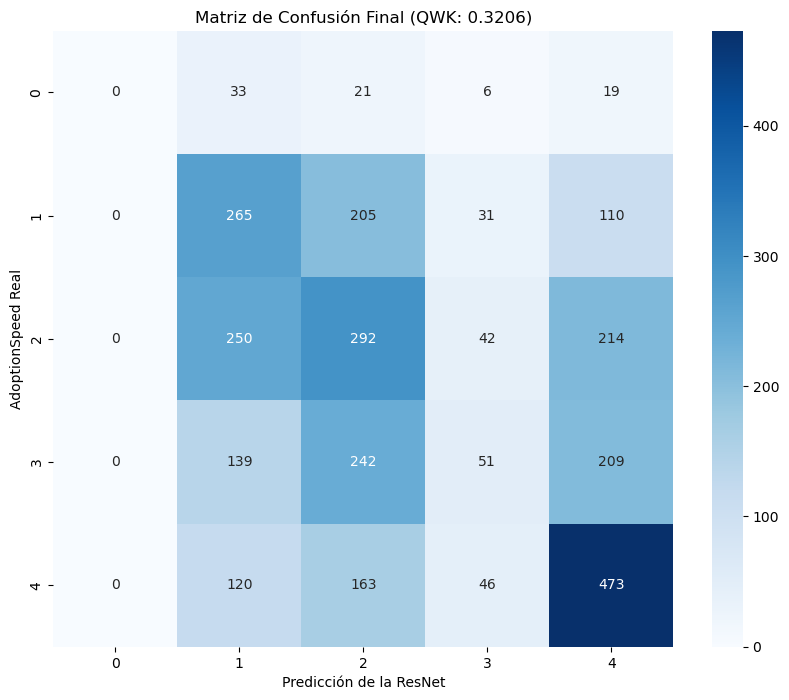

In [20]:
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Asegurar modo evaluación
best_model.eval()

all_preds = []
all_labels = []

# 2. Usamos el val_dataloader (que creaste a partir de tu split de test/val)
print("Calculando inferencia sobre el set de prueba...")
with torch.no_grad():
    for inputs, labels, _ in val_dataloader: # O test_dataloader si lo llamaste así
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Métricas
qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f"\nQuadratic Weighted Kappa Final: {qwk:.4f}")

# 4. Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel('Predicción de la ResNet')
plt.ylabel('AdoptionSpeed Real')
plt.title(f'Matriz de Confusión Final (QWK: {qwk:.4f})')
plt.show()

In [22]:
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

def extract_features_and_probs(model, dataloader, device):
    model.eval()
    features_list = []
    probs_list = []
    ids_list = []
    
    # Cortamos la última capa (Linear) para quedarnos con el Average Pooling de 2048 dimensiones
    extractor = torch.nn.Sequential(*list(model.children())[:-1])
    
    print(f"Extrayendo variables (2048) y probabilidades de clases...")
    
    with torch.no_grad():
        for inputs, _, petids in tqdm(dataloader):
            inputs = inputs.to(device)
            
            # 1. EXTRAER VARIABLES (2048 dims)
            f = extractor(inputs)
            # Aplanamos el tensor: pasa de (batch_size, 2048, 1, 1) a (batch_size, 2048)
            f = f.view(f.size(0), -1) 
            features_list.append(f.cpu().numpy())
            
            # 2. EXTRAER PROBABILIDADES DE CLASES (5 variables)
            outputs = model(inputs)
            # Aplicamos Softmax para convertirlos en probabilidades probabilísticas sumando 1
            probs = F.softmax(outputs, dim=1) 
            probs_list.append(probs.cpu().numpy())
            
            # Guardamos los PetIDs
            ids_list.extend(petids)
            
    # Concatenamos las listas de todos los batches
    feat_2048 = np.concatenate(features_list, axis=0)
    probs_all = np.concatenate(probs_list, axis=0)
    
    return ids_list, feat_2048, probs_all

In [23]:
import pandas as pd
from sklearn.decomposition import PCA
import torch

# ==========================================
# 1. PROCESAMIENTO DE TRAIN
# ==========================================
print("Extraendo características de Train...")
ids_train, feats_train, probs_train = extract_features_and_probs(best_model, train_dataloader, device)

print("Entrenando PCA para retener el 70% de la varianza...")
pca = PCA(n_components=0.70, random_state=42)
pca_train = pca.fit_transform(feats_train) # Ajustamos y transformamos

num_components = pca_train.shape[1]
print(f"✅ PCA ajustado. Se conservaron {num_components} componentes.")

# Guardar PCA Train
pca_cols = [f'resnet_pca_{i}' for i in range(num_components)]
df_pca_train = pd.DataFrame(pca_train, columns=pca_cols)
df_pca_train.insert(0, 'PetID', ids_train)
df_pca_train.to_csv('work/resnet_pca_features_train.csv', index=False)

# Guardar Probabilidades Train
prob_cols = [f'resnet_prob_class_{i}' for i in range(5)]
df_probs_train = pd.DataFrame(probs_train, columns=prob_cols)
df_probs_train.insert(0, 'PetID', ids_train)
df_probs_train.to_csv('work/resnet_probabilities_train.csv', index=False)


# ==========================================
# 2. PROCESAMIENTO DE VAL/TEST
# ==========================================
print("\nExtraendo características de Validación/Test...")
ids_val, feats_val, probs_val = extract_features_and_probs(best_model, val_dataloader, device)

# IMPORTANTE: Usamos el mismo objeto 'pca' entrenado arriba (solo transform)
pca_val = pca.transform(feats_val) 

# Guardar PCA Validación
df_pca_val = pd.DataFrame(pca_val, columns=pca_cols)
df_pca_val.insert(0, 'PetID', ids_val)
df_pca_val.to_csv('work/resnet_pca_features_test.csv', index=False)

# Guardar Probabilidades Validación
df_probs_val = pd.DataFrame(probs_val, columns=prob_cols)
df_probs_val.insert(0, 'PetID', ids_val)
df_probs_val.to_csv('work/resnet_probabilities_test.csv', index=False)

print(f"✅ Proceso completado. Archivos guardados en /work para Train y Test.")

Extraendo características de Train...
Extrayendo variables (2048) y probabilidades de clases...


100%|██████████| 92/92 [02:20<00:00,  1.53s/it]


Entrenando PCA para retener el 70% de la varianza...
✅ PCA ajustado. Se conservaron 155 componentes.

Extraendo características de Validación/Test...
Extrayendo variables (2048) y probabilidades de clases...


100%|██████████| 23/23 [00:15<00:00,  1.48it/s]


✅ Proceso completado. Archivos guardados en /work para Train y Test.


In [26]:
from joblib import dump

# Suponiendo que 'pca' es tu objeto de sklearn.decomposition.PCA ya fiteado
pca_filename = 'work/pca_model_resnet.joblib'
dump(pca, pca_filename)
print(f"Objeto PCA exportado exitosamente como {pca_filename}")

Objeto PCA exportado exitosamente como work/pca_model_resnet.joblib


In [23]:
import pandas as pd

# Cargamos una muestra del archivo
df_check = pd.read_csv('work/resnet_pca_features_train.csv')

# 1. Verificamos qué columnas tiene
print("Columnas en el archivo:", df_check.columns.tolist())

# 2. Vemos las primeras filas para entender la estructura
print("\nPrimeras filas:")
display(df_check.head())


Columnas en el archivo: ['PetID', 'resnet_pca_0', 'resnet_pca_1', 'resnet_pca_2', 'resnet_pca_3', 'resnet_pca_4', 'resnet_pca_5', 'resnet_pca_6', 'resnet_pca_7', 'resnet_pca_8', 'resnet_pca_9', 'resnet_pca_10', 'resnet_pca_11', 'resnet_pca_12', 'resnet_pca_13', 'resnet_pca_14', 'resnet_pca_15', 'resnet_pca_16', 'resnet_pca_17', 'resnet_pca_18', 'resnet_pca_19', 'resnet_pca_20', 'resnet_pca_21', 'resnet_pca_22', 'resnet_pca_23', 'resnet_pca_24', 'resnet_pca_25', 'resnet_pca_26', 'resnet_pca_27', 'resnet_pca_28', 'resnet_pca_29', 'resnet_pca_30', 'resnet_pca_31', 'resnet_pca_32', 'resnet_pca_33', 'resnet_pca_34', 'resnet_pca_35', 'resnet_pca_36', 'resnet_pca_37', 'resnet_pca_38', 'resnet_pca_39', 'resnet_pca_40', 'resnet_pca_41', 'resnet_pca_42', 'resnet_pca_43', 'resnet_pca_44', 'resnet_pca_45', 'resnet_pca_46', 'resnet_pca_47', 'resnet_pca_48', 'resnet_pca_49', 'resnet_pca_50', 'resnet_pca_51', 'resnet_pca_52', 'resnet_pca_53', 'resnet_pca_54', 'resnet_pca_55', 'resnet_pca_56', 'resnet

,PetID,resnet_pca_0,resnet_pca_1,resnet_pca_2,resnet_pca_3,resnet_pca_4,resnet_pca_5,resnet_pca_6,resnet_pca_7,resnet_pca_8,...,resnet_pca_145,resnet_pca_146,resnet_pca_147,resnet_pca_148,resnet_pca_149,resnet_pca_150,resnet_pca_151,resnet_pca_152,resnet_pca_153,resnet_pca_154
0,ec4ed9fe6,-6.796335,2.370845,2.747296,0.976126,1.102998,-0.368981,-3.094979,0.281444,-2.066648,...,-0.248660,0.591167,0.476774,-1.493573,0.308851,-0.386059,-0.161663,0.233849,0.655217,-0.419321
1,106de20f0,-11.701126,2.463176,0.009042,3.713975,2.205445,4.013631,0.224604,0.789193,-0.444797,...,-0.039560,0.766175,0.703014,-0.239411,-0.549020,0.044093,-0.673525,-0.621622,-0.706681,-0.423424
2,aee44eb09,-5.023552,2.176875,2.809171,1.316128,-1.165226,0.962662,-2.003343,-0.064017,-1.808640,...,-0.340719,-0.280128,-0.171255,0.060896,0.037818,0.717283,-0.132003,-0.329343,0.136263,-0.348904
3,98e1a3f01,-2.520311,0.398637,5.360640,-0.564324,1.861266,-1.318383,0.004628,1.591419,-1.388054,...,0.090061,0.538771,-0.432212,0.619304,0.609367,-0.088968,0.238478,0.521018,0.111841,0.259346
4,f4df06287,-0.922935,-3.234354,-0.929352,1.909441,-0.855348,-1.187696,-0.665150,-0.809250,-1.326202,...,0.138895,-0.183047,-0.227615,-0.051942,0.299178,-0.198553,0.774483,0.622028,0.392914,-0.260211


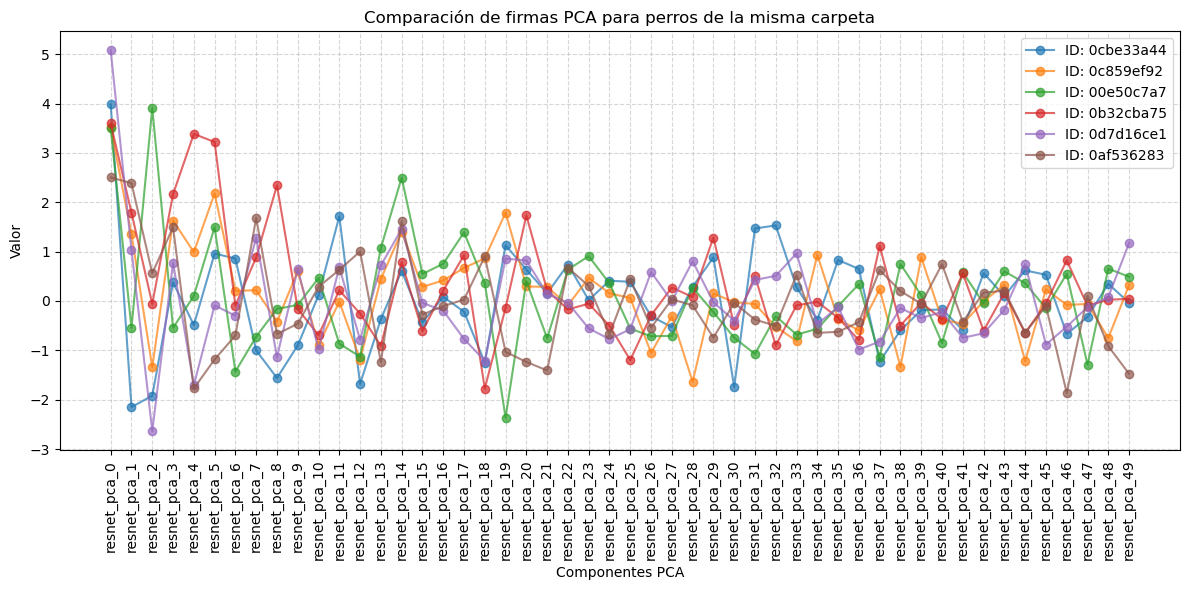


Promedio de los primeros 5 componentes para estos perros:
resnet_pca_0    3.695890
resnet_pca_1    0.644068
resnet_pca_2   -0.246780
resnet_pca_3    0.981024
resnet_pca_4    0.085701
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Para hacer verificación si el petid no se mezcló en los datos

# 1. Lista de PetIDs que sabes que están en la misma carpeta
# (Cambiá estos nombres por IDs reales que veas en tu carpeta)
ids_a_comparar = ['00e50c7a7',   '0b32cba75',  '0c859ef92',   '0cbe33a44',  '0d7d16ce1','0af536283'] # Agregá aquí los 5 o 6 IDs


#  primeros 5 corresponden a clase 1, el sexto  pet id=0af536283 corresponde a clase 4  

# 2. Cargamos el CSV
df = pd.read_csv('work/resnet_pca_features_train.csv')

# 3. Filtramos el DataFrame para obtener solo esos perros
df_subset = df[df['PetID'].isin(ids_a_comparar)]

if df_subset.empty:
    print("No se encontraron esos IDs en el CSV. Verificá que estén bien escritos.")
else:
    # 4. Graficamos los valores de PCA para comparar
    plt.figure(figsize=(12, 6))
    
    # Seleccionamos solo las columnas de PCA (omitimos 'PetID')
    # Usamos las primeras 50 variables para que el gráfico sea legible
    pca_cols = [c for c in df.columns if 'resnet_pca_' in c][:50]
    
    for _, row in df_subset.iterrows():
        plt.plot(pca_cols, row[pca_cols], marker='o', label=f"ID: {row['PetID']}", alpha=0.7)

    plt.xticks(rotation=90)
    plt.xlabel("Componentes PCA")
    plt.ylabel("Valor")
    plt.title(f"Comparación de firmas PCA para perros de la misma carpeta")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 5. Verificación de "Distancia" (Opcional)
    print("\nPromedio de los primeros 5 componentes para estos perros:")
    print(df_subset[pca_cols[:5]].mean())
